In [1]:
from pathlib import Path
from collections import Counter
import json

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from plot_functions import (
    LANDMARK_COLORS,
    finish_3d_axis,
    plot_landmark_classes,
    plot_landmark_projections,
    plot_landmarks_3d,
    sample_indices,
)


In [2]:
PROJECT = Path('/Users/nourlachtar/Documents/OrthoTwin3D')
RAW_DIR = PROJECT / "data" / "raw" / "Teeth3DS"
LANDMARK_DIR = PROJECT / "data" / "raw" / "Teeth3DSLandmarks"
DOWNLOAD_DIR = PROJECT / "data" / "raw" / "Teeth3DS_downloads"


In [3]:
# nombre de fichiers 
obj_files = sorted(RAW_DIR.rglob("*.obj"))
annotation_files = sorted(RAW_DIR.rglob("*.json"))
landmark_files = sorted(LANDMARK_DIR.rglob("*__kpt.json"))
split_files = sorted(RAW_DIR.rglob("*.txt"))
archive_files = sorted(DOWNLOAD_DIR.glob("*.zip"))

print("Archives .zip".ljust(30), ":", len(archive_files))
print("Scans .obj".ljust(30), ":", len(obj_files))
print("Annotations Teeth3DS .json".ljust(30), ":", len(annotation_files))
print("Landmarks *__kpt.json".ljust(30), ":", len(landmark_files))
print("Fichiers split .txt".ljust(30), ":", len(split_files))

Archives .zip                  : 10
Scans .obj                     : 1900
Annotations Teeth3DS .json     : 1800
Landmarks *__kpt.json          : 340
Fichiers split .txt            : 12


# exemple

### Mesh 3D

In [4]:
object_path = PROJECT / "data" / "raw" / "Teeth3DS" / "lower" / "0140W3ND" / "0140W3ND_lower.obj"

In [5]:
import trimesh
mesh = trimesh.load_mesh(object_path,process = False)


In [6]:
# coordonnée des points de scan 
mesh.vertices
#Rq le nombre de points de scan est different pour chaque scan 

TrackedArray([[  -2.3518888 ,   33.85327388, -105.62691858],
              [  -2.34697555,   33.88584211, -105.41941616],
              [  -2.35680439,   33.82069013, -105.8345199 ],
              ...,
              [  27.51191609,   -0.28407728,  -94.03129164],
              [  16.3364895 ,  -16.66641041,  -92.16065048],
              [ -11.6960081 ,   -9.91130969,  -86.33783369]],
             shape=(102848, 3))

In [7]:
# chaque ligne est un triangle 
mesh.faces 

TrackedArray([[   106,    656,    191],
              [   908,    124,    436],
              [  1375,    234,    461],
              ...,
              [ 32626, 102847,  58352],
              [102847, 101019,  16676],
              [ 37334, 101019, 102847]], shape=(205596, 3))

In [8]:
# les vecteurs normaux de chaque sommet du mesh.
mesh.vertex_normals

array([[-0.05772248,  0.98646709, -0.15346269],
       [-0.00489791,  0.57980998,  0.81473701],
       [-0.05772248,  0.98646709, -0.15346269],
       ...,
       [ 0.86443004, -0.32353749,  0.38481708],
       [ 0.39132725, -0.71029454,  0.58510225],
       [-0.62133484,  0.65937965,  0.42327473]], shape=(102848, 3))

### annotation

In [9]:
annotation_path = PROJECT / "data" / "raw" / "Teeth3DS" / "lower" / "0140W3ND" / "0140W3ND_lower.json"

In [10]:
with annotation_path.open("r", encoding="utf-8") as f:
    annotation = json.load(f)


In [11]:
annotation.keys()

dict_keys(['id_patient', 'jaw', 'labels', 'instances'])

**id_patient** : identifiant du patient ou du scan.

**jaw** : mâchoire concernée, avec upper pour la mâchoire supérieure et lower pour la mâchoire inférieure.

**labels** : label anatomique de la dent.

**instances** : identifiant d’instance par vertex. Tous les points appartenant au même objet dentaire, 

In [12]:
annotation["id_patient"]

'0140W3ND'

In [13]:
annotation["jaw"]

'lower'

In [14]:
np.array(annotation['labels'])

array([ 0,  0,  0, ...,  0,  0, 43], shape=(102848,))

In [15]:
np.array(annotation['instances'])

array([0, 0, 0, ..., 0, 0, 2], shape=(102848,))

In [16]:
def counter(L:list):
    counts = dict()

    for x in L:
        counts[str(x)] = counts.get(str(x), 0) + 1

    return(counts)

In [17]:
label_counts = counter(annotation['labels'])
for label, count in sorted(label_counts.items()):
    meaning = "gencive/fond" if label == 0 else "dent FDI"
    print(f"  {label:>2} : {count:>6} points  ({meaning})")

   0 :  34414 points  (dent FDI)
  31 :   2766 points  (dent FDI)
  32 :   3562 points  (dent FDI)
  33 :   4400 points  (dent FDI)
  34 :   4181 points  (dent FDI)
  35 :   5345 points  (dent FDI)
  36 :   7819 points  (dent FDI)
  37 :   5496 points  (dent FDI)
  41 :   3076 points  (dent FDI)
  42 :   3782 points  (dent FDI)
  43 :   3927 points  (dent FDI)
  44 :   4390 points  (dent FDI)
  45 :   4985 points  (dent FDI)
  46 :   8683 points  (dent FDI)
  47 :   6022 points  (dent FDI)


In [18]:
instances = counter(annotation['instances'])
for label, count in sorted(instances.items()):
    meaning = "gencive/fond" if label == 0 else "dent FDI"
    print(f"  {label:>2} : {count:>6} points  ({meaning})")

   0 :  34414 points  (dent FDI)
   1 :   6022 points  (dent FDI)
  10 :   8683 points  (dent FDI)
  11 :   3076 points  (dent FDI)
  12 :   2766 points  (dent FDI)
  13 :   3562 points  (dent FDI)
  14 :   3782 points  (dent FDI)
   2 :   3927 points  (dent FDI)
   3 :   7819 points  (dent FDI)
   4 :   5496 points  (dent FDI)
   5 :   4390 points  (dent FDI)
   6 :   4181 points  (dent FDI)
   7 :   5345 points  (dent FDI)
   8 :   4985 points  (dent FDI)
   9 :   4400 points  (dent FDI)


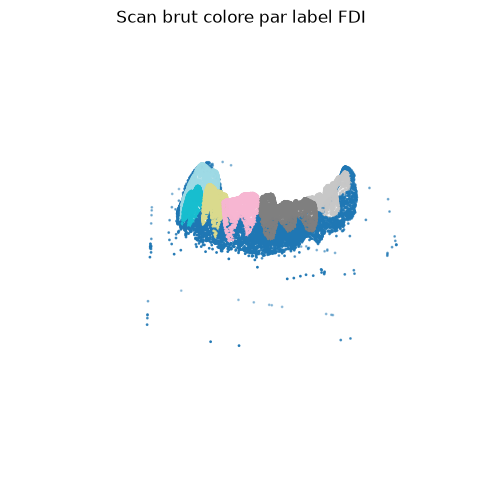

In [19]:
vertices = np.asarray(mesh.vertices, dtype=np.float32)
faces = np.asarray(mesh.faces, dtype=np.int64)
normals = np.asarray(mesh.vertex_normals, dtype=np.float32)
labels = np.asarray(annotation["labels"], dtype=np.int64)
instances = np.asarray(annotation["instances"], dtype=np.int64)
max_points = 20000
rng = np.random.default_rng(0)
if len(vertices) > max_points:
    plot_idx = rng.choice(len(vertices), size=max_points, replace=False)
else:
    plot_idx = np.arange(len(vertices))

plot_vertices = vertices[plot_idx]
plot_labels = labels[plot_idx]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(plot_vertices[:, 0], plot_vertices[:, 1], plot_vertices[:, 2], c=plot_labels, s=1, cmap="tab20")
ax.set_title("Scan brut colore par label FDI")
ax.set_axis_off()
ax.view_init(elev=20, azim=-70)
plt.show()


### Landmarks 

In [20]:
landmark_file = PROJECT /'data'/"raw"/"Teeth3DSLandmarks"/"lower"/"0140W3ND"/"0140W3ND_lower__kpt.json"

with landmark_file.open("r", encoding="utf-8") as f:
    landmark_data = json.load(f)

In [21]:
landmark_data.keys()

dict_keys(['version', 'description', 'key', 'objects'])


**`key`** : identifiant du groupe de landmarks,"{scan_id}_{jaw}"

`objects`
Liste des landmarks associés au scan.

Chaque élément contient :

| Attribut | Signification |
|---|---|
| `key` | Identifiant du landmark. |
| `class` | Classe anatomique du landmark. |
| `coord` | Coordonnées 3D du landmark|


In [22]:
landmark_data["objects"]

[{'key': 'uuid_0',
  'class': 'Mesial',
  'coord': [2.0061191493734833, -19.068454466783685, -84.77027362115311]},
 {'key': 'uuid_1',
  'class': 'Mesial',
  'coord': [1.4228051010090907, -17.4974567802855, -84.02839898277854]},
 {'key': 'uuid_2',
  'class': 'Mesial',
  'coord': [6.225194782524131, -16.74380986191343, -84.51581497121187]},
 {'key': 'uuid_3',
  'class': 'Mesial',
  'coord': [12.43989749860417, -14.490737511331517, -84.955223833806]},
 {'key': 'uuid_4',
  'class': 'Mesial',
  'coord': [14.490802206781376, -8.800727725033386, -88.32807891274541]},
 {'key': 'uuid_5',
  'class': 'Mesial',
  'coord': [19.5678074812447, -3.5150029301781007, -88.8926096116428]},
 {'key': 'uuid_6',
  'class': 'Mesial',
  'coord': [21.183247349999043, 4.242832145110455, -89.66140063846782]},
 {'key': 'uuid_7',
  'class': 'Mesial',
  'coord': [23.79847038701956, 14.731461126415544, -89.53468738861126]},
 {'key': 'uuid_8',
  'class': 'Mesial',
  'coord': [-9.271841600476524, -14.829451315135913, -8

In [23]:
landmark_objects = landmark_data.get("objects", [])
if landmark_objects:
    landmark_coords = np.asarray([obj["coord"] for obj in landmark_objects], dtype=np.float32)
    landmark_labels = np.asarray([obj["class"] for obj in landmark_objects])
else:
    landmark_coords = np.empty((0, 3), dtype=np.float32)
    landmark_labels = np.asarray([])

print("points affiches:", len(plot_vertices), "/", len(vertices))
print("landmarks affiches:", len(landmark_coords))

points affiches: 20000 / 102848
landmarks affiches: 97


Classes de landmarks présentes dans la base de données

| Classe | Résumé |
|---|---|
| `Cusp` | Pointe ou relief haut de la dent. |
| `Mesial` | Côté orienté vers le centre de l’arcade dentaire. |
| `Distal` | Côté opposé au centre de l’arcade dentaire. |
| `FacialPoint` | Point côté visage : lèvres ou joues. |
| `InnerPoint` | Point côté intérieur : langue ou palais. |
| `OuterPoint` | Point côté extérieur de l’arcade. |

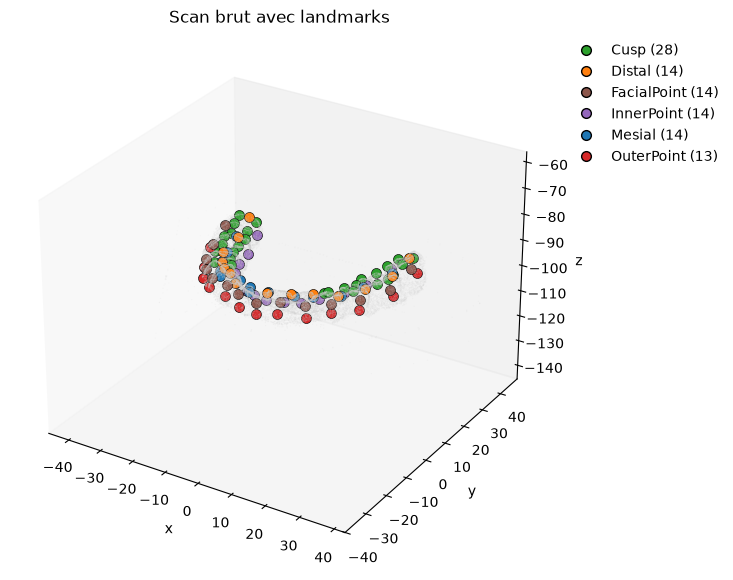

In [24]:
fig, ax = plot_landmarks_3d(
    vertices=vertices,
    landmark_coords=landmark_coords,
    landmark_labels=landmark_labels,
    colors=LANDMARK_COLORS,
    title="Scan brut avec landmarks",
)
plt.show()

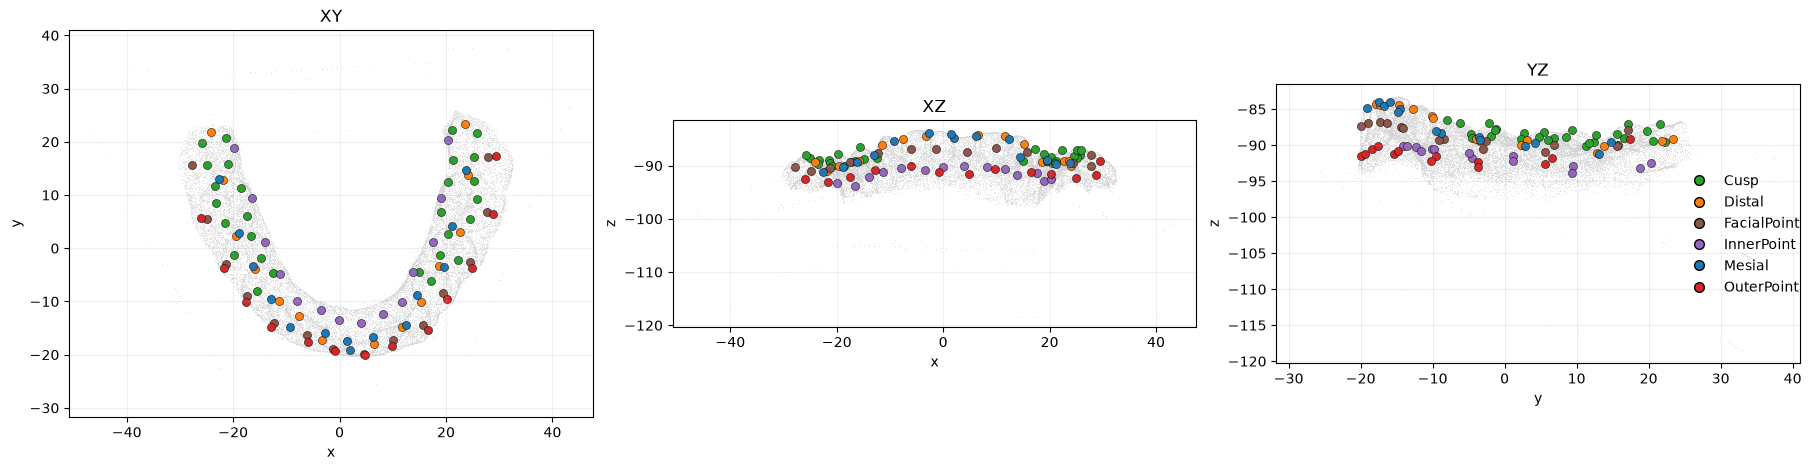

In [36]:
fig, axes = plot_landmark_projections(
    vertices=vertices,
    landmark_coords=landmark_coords,
    landmark_labels=landmark_labels,
    colors=LANDMARK_COLORS,
)
plt.show()

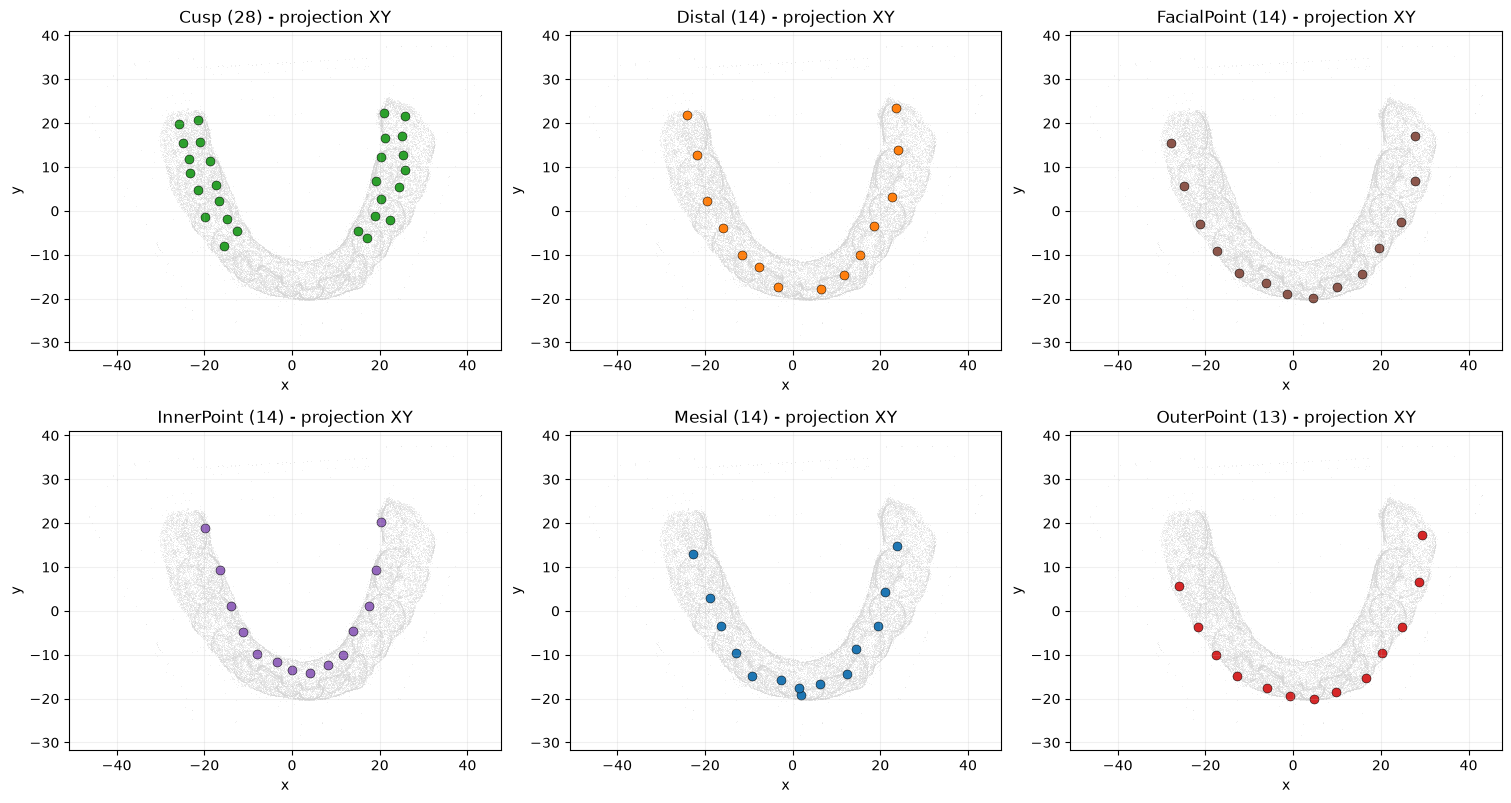

In [37]:
fig, axes = plot_landmark_classes(
    vertices=vertices,
    landmark_coords=landmark_coords,
    landmark_labels=landmark_labels,
    colors=LANDMARK_COLORS,
    axes_pair=(0, 1),  # XY. Utilise (0, 2) pour XZ ou (1, 2) pour YZ.
)
plt.show()